#Actividad 1: Análisis de Ventas y Productos
Consigna:

Cargá los conjuntos de datos que contienen la información sobre las ventas, productos y clientes.

Explorá cada DataFrame.

Limpiá los datos, eliminando duplicados y manejando valores nulos. Asegurate de que las columnas de fecha estén en el formato adecuado.

Ideá una manera de calcular el total gastado por cada cliente.

En cada paso, documentá tus hallazgos y las modificaciones que vas aplicando.

Realizá un análisis de las ventas por categoría de producto y visualiza los resultados utilizando gráficos de barras.

# 1 - Cargá los conjuntos de datos que contienen la información sobre las ventas, productos y clientes.

In [ ]:
import pandas as pd

#Todas las salidas de pandas mostrarán por defecto dos decimales
pd.set_option('display.precision', 2)
#Todas las salidas mostraran números completos
pd.set_option('display.float_format', '{:.2f}'.format)

ventas = pd.read_csv('https://drive.google.com/uc?id=18FuPA04nSGC16PKqQWNnCjEe74MEMeYR')
productos = pd.read_csv('https://drive.google.com/uc?id=1jqTcoLstwu3lwmjZpY78R7CY6-XdQBJD')
clientes = pd.read_csv('https://drive.google.com/uc?id=1Zucy51Q7S9-U3TBneiOy4zhF5fiti_CU')


# 2 - Explorá cada DataFrame.

## Exploración df_ventas

In [ ]:
ventas.head()

In [ ]:
ventas.info()

In [ ]:
describe_ventas = ventas[['Cantidad']].describe()
describe_ventas['Cantidad'] = describe_ventas['Cantidad'].astype(int)
describe_ventas

## Exploración df_productos

In [ ]:
productos.head()

In [ ]:
productos.info()

In [ ]:
describe_productos = productos[['Precio_Unitario', 'Stock']].describe()
describe_productos['Stock'] = describe_productos['Stock'].astype(int)
describe_productos

## Exploración df_clientes

In [ ]:
clientes.head()

In [ ]:
clientes.info()

In [ ]:
# Convertir tipo de datos de la columna Ingreso para
# trabajarlo como dato numérico
clientes['Ingresos'] = clientes['Ingresos'].str.replace('$', '').astype(float)

In [ ]:
clientes[['Edad', 'Ingresos']].describe()

## 3- Limpiá los datos, eliminando duplicados y manejando valores nulos. Asegurate de que las columnas de fecha estén en el formato adecuado.

In [ ]:
print("Duplicados df_ventas : ", ventas.duplicated().sum(), " de : ", len(ventas))
print("representa el : ", round(ventas.duplicated().sum() / len(ventas) * 100, 2), "%")
print("Duplicados df_productos : ", productos.duplicated().sum(), " de : ", len(productos))
print("representa el : ", round(productos.duplicated().sum() / len(productos) * 100, 2), "%")
print("Duplicados df_clientes : ", clientes.duplicated().sum(), " de : ", len(clientes))
print("representa el : ", round(clientes.duplicated().sum() / len(clientes) * 100, 2), "%")

In [ ]:
# Ver productos repetidos
productos_repetidos = productos[productos.duplicated(subset='Nombre_Producto', keep=False)]
productos_repetidos

###Eliminar duplicados en los tres df.
Tanto en df_ventas como en df_clientes el porcentaje de duplicados es bajo. En df_productos si bien el porcentaje de duplicados es significativo, los registros duplicados no resultan determinantes para el análisis.  

In [ ]:
ventas = ventas.drop_duplicates()
productos = productos.drop_duplicates()
clientes = clientes.drop_duplicates()

In [ ]:
# Valores no nulos por df
print("Valores nulos df_ventas : \n", ventas.isnull().sum(), "\n")
print("Valores nulos df_productos :\n ", productos.isnull().sum(), "\n")
print("Valores nulos df_clientes :\n ", clientes.isnull().sum())




###Se cambia el formato de la columna 'Fecha' del df_ventas.

In [ ]:
ventas['Fecha'] = pd.to_datetime(ventas['Fecha'], format='%d/%m/%Y')

##4- Ideá una manera de calcular el total gastado por cada cliente.

In [ ]:
df_ventas_clientes = pd.merge(left=ventas, right=clientes, how='inner', on='ID_Cliente', indicator=True)
#verifica que todos los id tengan coincidencia para no perder registros
df_ventas_clientes['_merge'].value_counts()

In [ ]:
ingresos_por_cliente = df_ventas_clientes.groupby('ID_Cliente')['Ingresos'].sum()


##6- Realizá un análisis de las ventas por categoría de producto y visualiza los resultados utilizando gráficos de barras.

In [ ]:
df_ventas_productos = pd.merge(left=ventas, right=productos, how='inner', on='ID_Producto', indicator=True)
#verifica que todos los id tengan coincidencia para no perder registros
df_ventas_productos['_merge'].value_counts()
#crea nueva columna 'Precio_Final', multiplica la cantidad del produdto vendido por el precio unitario del mismo
df_ventas_productos['Precio_Final'] = df_ventas_productos['Cantidad'] * df_ventas_productos['Precio_Unitario']

In [ ]:
ventas_por_productos = df_ventas_productos.groupby('ID_Producto')['Precio_Final'].sum()

#####Usando pandas

<Axes: title={'center': 'Ventas por Producto'}, xlabel='ID_Producto'>

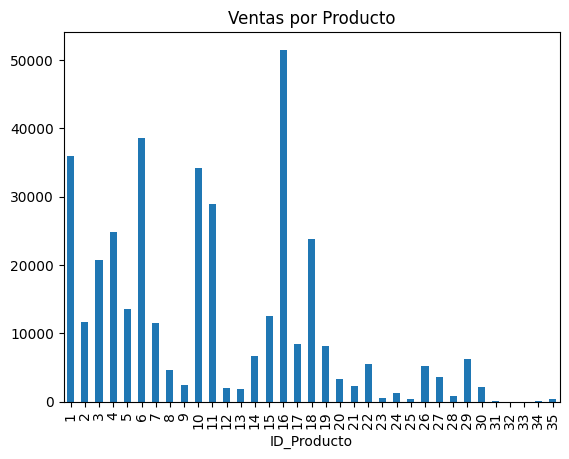

In [ ]:
ventas_por_productos.plot(kind='bar', title='Ventas por Producto')

#### Usando matplotilib

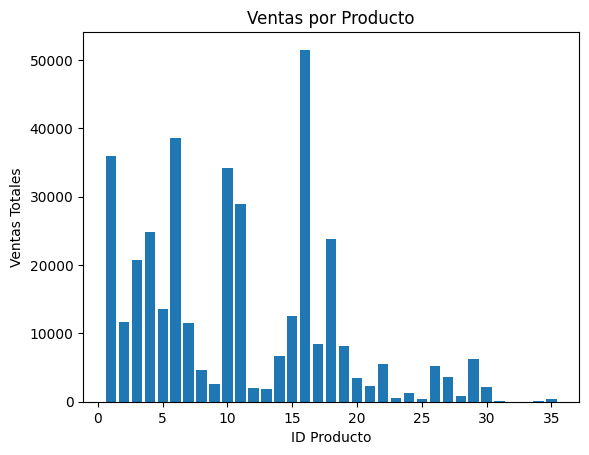

In [ ]:
import matplotlib.pyplot as plt

plt.bar(ventas_por_productos.index, ventas_por_productos.values)
plt.xlabel('ID Producto')
plt.ylabel('Ventas Totales')
plt.title('Ventas por Producto')
plt.show()

####Usando seaborn

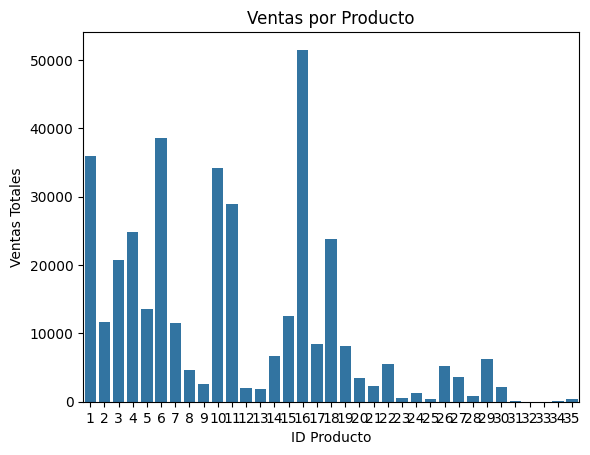

In [ ]:
import seaborn as sns

sns.barplot(x=ventas_por_productos.index, y=ventas_por_productos.values)
plt.xlabel('ID Producto')
plt.ylabel('Ventas Totales')
plt.title('Ventas por Producto')
plt.show()